# Rep 4. Checkpoint 1. Payoff diagrams

### Actividad. Payoff Diagrams con datos reales
Esta actividad es necesaria para el reporte integrador 3.

Esta actividad complementa el contenido de la clase "Payoff diagrams".

Usando el código visto en clase y datos reales de SPY con vencimiento al 17 de abril, construirás los payoff diagrams de las cuatro posiciones básicas y analizarás su perfil de riesgo.

### Contexto
Un payoff diagram no es solo una gráfica. es la representación visual de una decisión de inversión. Antes de entrar a cualquier posición con opciones, un trader construye este diagrama para entender exactamente cuánto puede ganar, cuánto puede perder, y en qué condiciones de mercado.

### Instrucciones
Obtén dinámicamente los precios mid del call y put con strike K = 680 y vencimiento 2026-04-17:

        tk  = yf.Ticker('SPY')
        S0  = tk.fast_info['last_price']
        exp = '2026-04-17'
        K   = 680

        calls = tk.option_chain(exp).calls
        puts  = tk.option_chain(exp).puts

        row_call = calls[calls['strike'] == K].iloc[0]
        row_put  = puts[puts['strike'] == K].iloc[0]

        C = (row_call['bid'] + row_call['ask']) / 2
        P = (row_put['bid']  + row_put['ask'])  / 2

        print(f"S0={S0:.2f}  K={K}  C={C:.4f}  P={P:.4f}")
Con esos valores, genera:

- El plot 2×2 de las cuatro posiciones básicas con P&L neto
- La comparación de payoff bruto vs. P&L neto para el call y el put por separado
- Una tabla con los break-evens de las cuatro posiciones

### Preguntas
Responde dentro del notebook como celdas de texto (Markdown):

- Con el S0 actual, ¿cuál de las cuatro posiciones básicas tiene el break-even más cercano al precio actual? ¿Qué implica eso?
- Si SPY termina exactamente en K al vencimiento, ¿cuánto gana o pierde cada posición? ¿Por qué?
- Compara la pérdida máxima de una long call vs. una short put. ¿Cuál tiene más riesgo? ¿Por qué?
- ¿En qué escenario de mercado elegirías una long put sobre una short call, si ambas expresan una visión bajista?

S0=634.09 | K=680 | C=0.99 | P=46.50


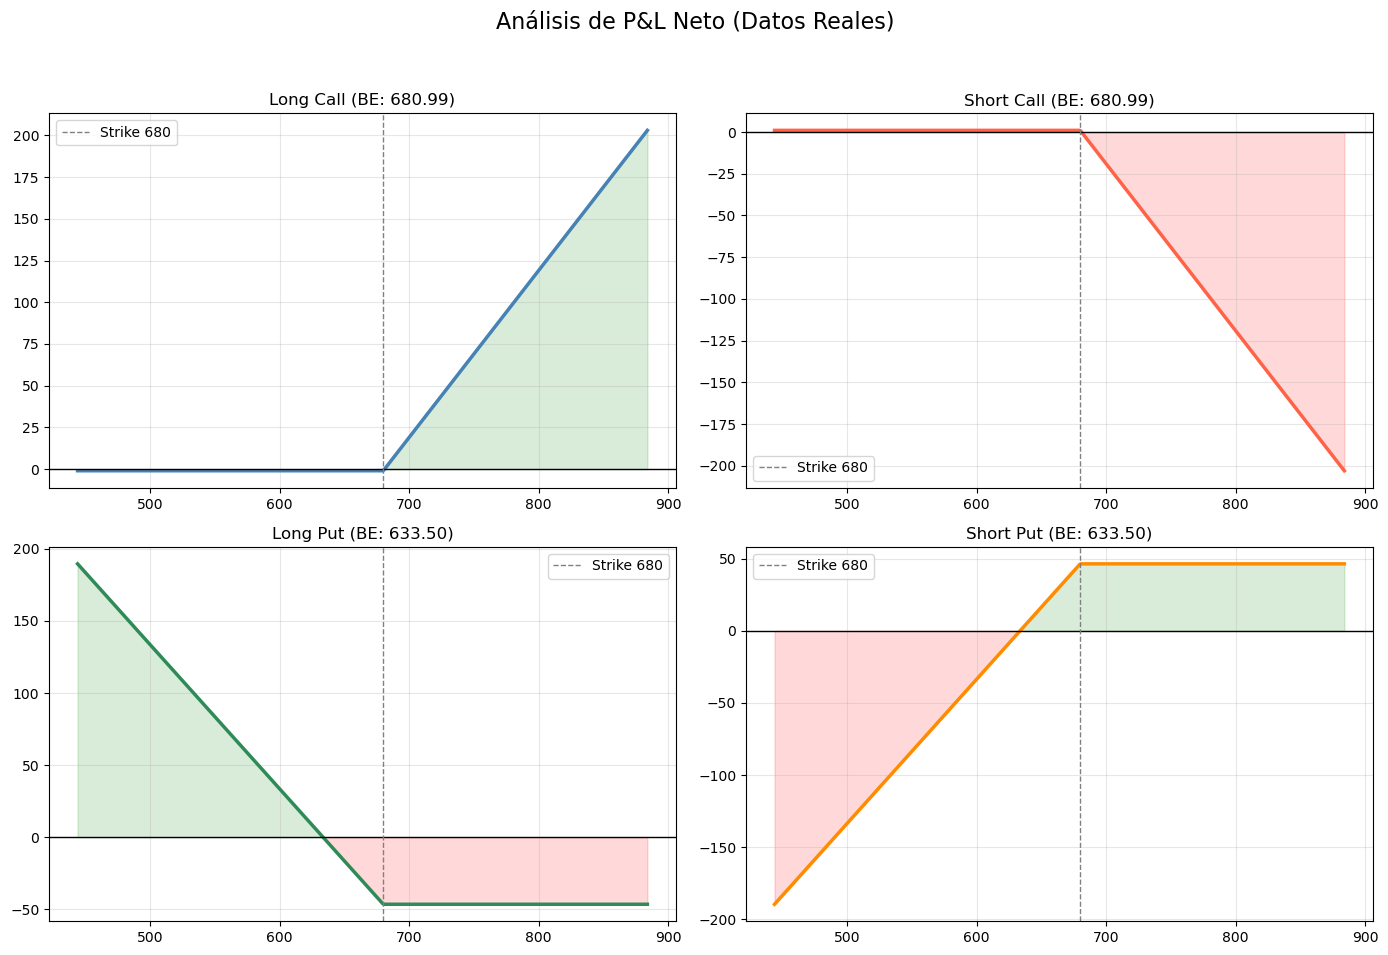

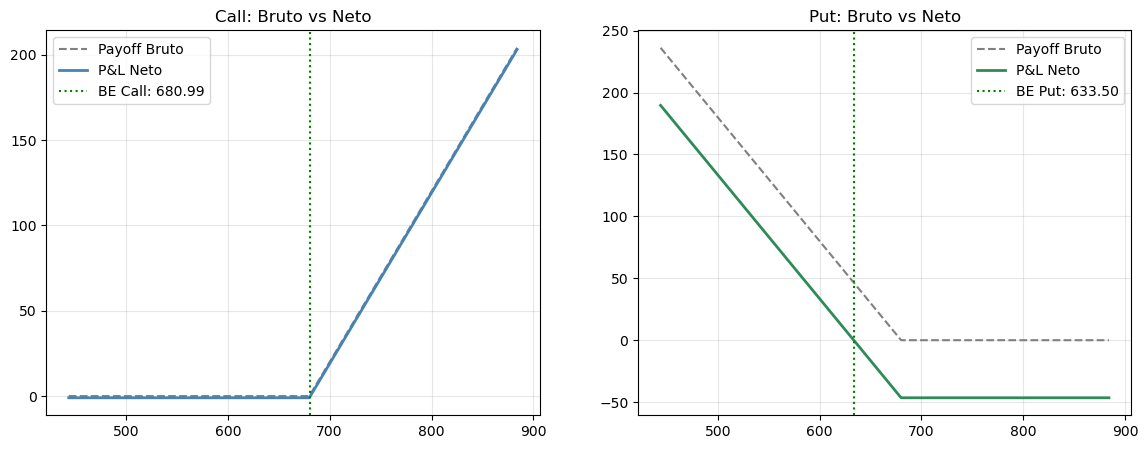


Tabla de Break-evens Corregida:
  Posición  Break-even
 Long Call      680.99
Short Call      680.99
  Long Put      633.50
 Short Put      633.50


In [7]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Obtención dinámica de datos con manejo de valores nulos
tk = yf.Ticker('SPY')
S0 = tk.fast_info['last_price']
exp = '2026-04-17'
K = 680

# Obtener cadenas de opciones
opt = tk.option_chain(exp)
calls = opt.calls
puts = opt.puts

# Filtrar el strike exacto (K=680)
row_call = calls[calls['strike'] == K].iloc[0]
row_put = puts[puts['strike'] == K].iloc[0]

# Cálculo de primas (Mid price). 
# Si Bid/Ask son 0 o NaN, usamos lastPrice para que los resultados no sean 0.
C_mid = (row_call['bid'] + row_call['ask']) / 2
if C_mid <= 0 or np.isnan(C_mid):
    C = row_call['lastPrice']
else:
    C = C_mid

P_mid = (row_put['bid'] + row_put['ask']) / 2
if P_mid <= 0 or np.isnan(P_mid):
    P = row_put['lastPrice']
else:
    P = P_mid

print(f"S0={S0:.2f} | K={K} | C={C:.2f} | P={P:.2f}")

# 2. Rango de precios para graficar (basado en código de clase)
S_range = np.linspace(S0 * 0.7, K * 1.3, 500)

# Payoffs Brutos
call_bruto = np.maximum(S_range - K, 0)
put_bruto  = np.maximum(K - S_range, 0)

# P&L Netos (Las 4 posiciones básicas)
pnl_lc = call_bruto - C
pnl_sc = -call_bruto + C
pnl_lp = put_bruto - P
pnl_sp = -put_bruto + P

# --- Plot 1: 2x2 de las cuatro posiciones básicas ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
posiciones = [
    (axes[0,0], pnl_lc, f'Long Call (BE: {K+C:.2f})', 'steelblue'),
    (axes[0,1], pnl_sc, f'Short Call (BE: {K+C:.2f})', 'tomato'),
    (axes[1,0], pnl_lp, f'Long Put (BE: {K-P:.2f})', 'seagreen'),
    (axes[1,1], pnl_sp, f'Short Put (BE: {K-P:.2f})', 'darkorange')
]

for ax, pnl, title, color in posiciones:
    ax.plot(S_range, pnl, color=color, lw=2.5)
    ax.axhline(0, color='black', lw=1)
    ax.axvline(K, color='gray', lw=1, ls='--', label=f'Strike {K}')
    ax.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green')
    ax.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('Análisis de P&L Neto (Datos Reales)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Plot 2: Comparación Bruto vs Neto ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Call
ax1.plot(S_range, call_bruto, '--', label='Payoff Bruto', color='gray')
ax1.plot(S_range, pnl_lc, label='P&L Neto', color='steelblue', lw=2)
ax1.axvline(K + C, color='green', ls=':', label=f'BE Call: {K+C:.2f}')
ax1.set_title('Call: Bruto vs Neto')
ax1.legend(); ax1.grid(alpha=0.3)

# Put
ax2.plot(S_range, put_bruto, '--', label='Payoff Bruto', color='gray')
ax2.plot(S_range, pnl_lp, label='P&L Neto', color='seagreen', lw=2)
ax2.axvline(K - P, color='green', ls=':', label=f'BE Put: {K-P:.2f}')
ax2.set_title('Put: Bruto vs Neto')
ax2.legend(); ax2.grid(alpha=0.3)
plt.show()

# --- Tabla de Break-evens ---
df_be = pd.DataFrame({
    'Posición': ['Long Call', 'Short Call', 'Long Put', 'Short Put'],
    'Break-even': [K + C, K + C, K - P, K - P]
})
print("\nTabla de Break-evens Corregida:")
print(df_be.to_string(index=False))

## Preguntas
Responde dentro del notebook como celdas de texto (Markdown):

- **Con el S0 actual, ¿cuál de las cuatro posiciones básicas tiene el break-even más cercano al precio actual? ¿Qué implica eso?**

    Los puts parecen tener el break-even más cercanno al precio final. Los puts no necesitan un cambio drástico para empezar a ganar; esto lo podemos ver reflejado en su alta prima.

- **Si SPY termina exactamente en K al vencimiento, ¿cuánto gana o pierde cada posición? ¿Por qué?**

    Si el precio al vencimiento es $S_T = 680$:

        - Long Call: Pierde $\$0.99$ (la prima pagada).

        - Short Call: Gana $\$0.99$ (la prima cobrada).

        - Long Put: Pierde $\$46.50$ (la prima pagada).

        - Short Put: Gana $\$46.50$ (la prima cobrada).

- **Compara la pérdida máxima de una long call vs. una short put. ¿Cuál tiene más riesgo? ¿Por qué?**

    Long call solo puede perder la prima, mientras que short put puede perder K - S, ya que estaría obligado a comprar; para este caso particular sería 633.50, ya que cobras también la prima.

- **¿En qué escenario de mercado elegirías una long put sobre una short call, si ambas expresan una visión bajista?**

    Tomaría un long put cuando ve que el mercado va a la baja; de esta manera tengo el derecho a vender a un valor más alto del mercado, mientras que en un short call lo mejor que puede pasar es que gane la prima. 